In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/gracilianakascher/background/BACKGROUND.png


In [2]:
# Baixa e descompacta o dataset direto no ambiente do Kaggle
!pip install --upgrade gdown
!gdown https://drive.google.com/uc?id=1K5gNxQ7RXA-nb4boNzPYQTJlRvJyYBD1 -O dataset.zip
!unzip -q dataset.zip -d /kaggle/working/raw_images/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.0 MB/s eta 0:00:00
  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.2
    Uninstalling gdown-5.2.2:
      Successfully uninstalled gdown-5.2.2
Downloading...
From (original): https://drive.google.com/uc?id=1K5gNxQ7RXA-nb4boNzPYQTJlRvJyYBD1
From (redirected): https://drive.google.com/uc?id=1K5gNxQ7RXA-nb4boNzPYQTJlRvJyYBD1&confirm=t&uuid=a934124c-8cc5-4d7c-b676-0f2c97a14c17
To: /kaggle/working/dataset.zip
100%|███████████████████████████████████████| 32.2M/32.2M [00:00<00:00, 114MB/s]


In [3]:
# ==============================================================================
# SEÇÃO 1: CONFIGURAÇÃO E IMPORTAÇÃO DE BIBLIOTECAS
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')
from IPython.display import HTML, Markdown, display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os
import sys
from tqdm import tqdm
import cv2
import shutil

import importlib

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Algoritmos
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
try:
    from xgboost import XGBRegressor
    from lightgbm import LGBMRegressor
    HAS_BOOSTING = True
except ImportError:
    HAS_BOOSTING = False

# Estilo dos Gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


In [4]:
# Configure Pandas display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [5]:
# Configure Visualization Settings
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cbd5e1'
plt.rcParams['axes.linewidth'] = 1.2
sns.set_theme(style="whitegrid", font="sans-serif")

In [6]:
# Suppress Non-Critical Warnings
warnings.filterwarnings('ignore')

print("✓ All core libraries imported successfully!")
print("✓ Matplotlib & Seaborn visualization themes applied.")

✓ All core libraries imported successfully!
✓ Matplotlib & Seaborn visualization themes applied.


In [7]:


GITHUB_USER = "Graciliana"
REPO_NAME = "computer_vision_project_sctech"
BRANCH = "development"

REPO_PATH = f"/kaggle/working/{REPO_NAME}"

# Clona ou atualiza o repositório
if not os.path.exists(REPO_PATH):
    !git clone -b {BRANCH} https://github.com/{GITHUB_USER}/{REPO_NAME}.git
    %cd {REPO_PATH}
else:
    %cd {REPO_PATH}
    !git checkout {BRANCH}
    !git pull origin {BRANCH}

Cloning into 'computer_vision_project_sctech'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 28 (delta 12), reused 18 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 6.69 KiB | 2.23 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/kaggle/working/computer_vision_project_sctech


In [8]:
%cd /kaggle/working/computer_vision_project_sctech

# Atualiza os arquivos com a versão limpa do GitHub
!git pull origin development

# Importa novamente os módulos
import src.utils
import src.pipeline

importlib.reload(src.utils)
importlib.reload(src.pipeline)

from src.pipeline import preprocess_image
from src.utils import load_images_from_folder, save_image

print("Módulos importados com sucesso!")

/kaggle/working/computer_vision_project_sctech
From https://github.com/Graciliana/computer_vision_project_sctech
 * branch            development -> FETCH_HEAD
Already up to date.
Módulos importados com sucesso!


In [9]:
# Ajuste o RAW_DIR para a pasta onde você descompactou/baixou as imagens no Kaggle
# (Geralmente fica em /kaggle/working/raw_images ou no /kaggle/input/...)
RAW_DIR = "/kaggle/working/raw_images"
PROCESSED_DIR = "/kaggle/working/processed_images"

# 1. Carrega todas as rotas das imagens do diretório de entrada
image_paths = load_images_from_folder(RAW_DIR)

# Exibe as 3 primeiras imagens encontradas para verificação
print("Exemplo de caminhos encontrados:", image_paths[:3])

[INFO] Encontradas 1300 imagens em: /kaggle/working/raw_images
Exemplo de caminhos encontrados: ['/kaggle/working/raw_images/casting_512x512/def_front/cast_def_0_8067.jpeg', '/kaggle/working/raw_images/casting_512x512/def_front/cast_def_0_2483.jpeg', '/kaggle/working/raw_images/casting_512x512/def_front/cast_def_0_3704.jpeg']


In [10]:
# Processa em lote
success_count = 0
for img_path in tqdm(image_paths, desc="Processando imagens"):
    try:
        # Aplica o pipeline do OpenCV
        processed_img = preprocess_image(img_path, target_size=(256, 256))
        
        # Mantém a estrutura de subpastas (/ok_front e /def_front)
        relative_path = os.path.relpath(img_path, RAW_DIR)
        output_path = os.path.join(PROCESSED_DIR, relative_path)
        
        # Salva no Kaggle
        save_image(output_path, processed_img)
        success_count += 1
    except Exception as e:
        print(f"Erro ao processar {img_path}: {e}")

print(f"\n[SUCESSO] {success_count} de {len(image_paths)} imagens processadas e salvas em: {PROCESSED_DIR}")

Processando imagens: 100%|██████████| 1300/1300 [00:05<00:00, 240.21it/s]


[SUCESSO] 1300 de 1300 imagens processadas e salvas em: /kaggle/working/processed_images


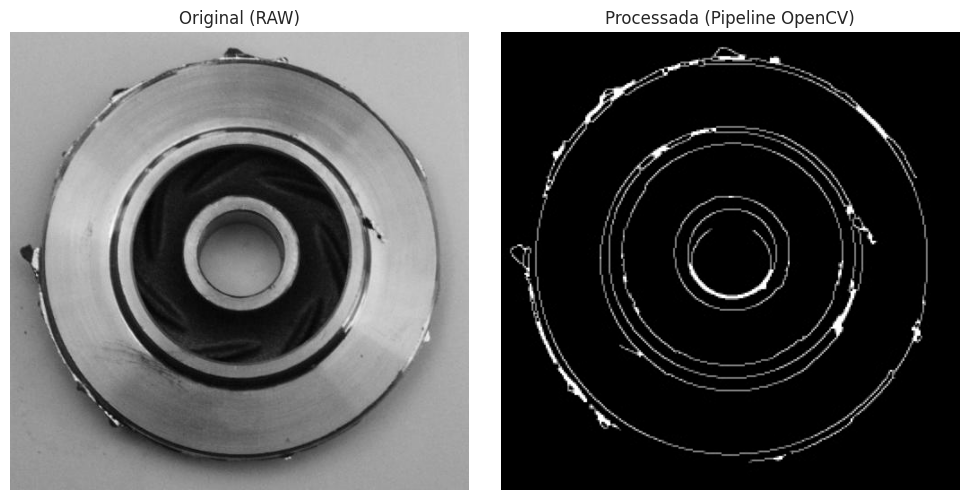

In [11]:


# Pega a primeira imagem para exibição
sample_raw_path = image_paths[0]
sample_processed_path = os.path.join(PROCESSED_DIR, os.path.relpath(sample_raw_path, RAW_DIR))

# Carrega as imagens
img_original = cv2.imread(sample_raw_path)
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
img_processed = cv2.imread(sample_processed_path, cv2.IMREAD_GRAYSCALE)

# Plota lado a lado
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_original)
axes[0].set_title("Original (RAW)")
axes[0].axis("off")

axes[1].imshow(img_processed, cmap="gray")
axes[1].set_title("Processada (Pipeline OpenCV)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [12]:


# Compacta a pasta de imagens processadas
shutil.make_archive("/kaggle/working/processed_images_export", 'zip', PROCESSED_DIR)
print("Arquivo /kaggle/working/processed_images_export.zip gerado com sucesso!")

Arquivo /kaggle/working/processed_images_export.zip gerado com sucesso!
